# Combined Transcriptomics Cleaning
Processes 2019_UGA, 2020_UGA, and SDY2867 with a shared pipeline, then concatenates into a single parquet.

In [25]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from combat.pycombat import pycombat
from sklearn.decomposition import PCA

from data_cleaning.utils import peek

DATA_PATH = "../../data"
CLEAN_DATA_PATH = "../../cleaned_data"
MIN_PRESENT = 1  # drop any column with less than % non-NaN values

In [14]:
unique_genes_challenge = set(
    pd.read_csv(DATA_PATH + '/challenge_transcriptomics.tsv', sep='\t')['ensembl_gene_id'].unique()
)
print(f"Challenge genes: {len(unique_genes_challenge)}")

Challenge genes: 54902


In [15]:
df_2019_uga = pd.read_csv(DATA_PATH + '/train_transcriptomics_2019_UGA.tsv', sep='\t')
df_2020_uga = pd.read_csv(DATA_PATH + '/train_transcriptomics_2020_UGA.tsv', sep='\t')
df_sdy2867 = pd.read_csv(DATA_PATH + '/train_transcriptomics_SDY2867.tsv', sep='\t')

df_raw = pd.concat([df_2019_uga, df_2020_uga, df_sdy2867], axis=0).reset_index(drop=True)
print(f"Combined raw: {df_raw.shape}")
df_raw.head()

Combined raw: (56162050, 7)


,transcriptomics_id,participant_id,timepoint,ensembl_gene_id,raw_count,tpm_count,material
0,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000003,NaN,0.077926,Unknown
1,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000005,NaN,0.000000,Unknown
2,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000419,NaN,5.342548,Unknown
3,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000457,NaN,9.799336,Unknown
4,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000460,NaN,2.118530,Unknown


In [16]:
# Basic preprocessing, drop unused cols, and genes not in common with the challenge set
df = df_raw.drop(columns=['transcriptomics_id', 'raw_count', 'material'])
df = df[df['timepoint'].isin([
    0
    # 7  # too much missingness
])]
df = df[df['ensembl_gene_id'].isin(unique_genes_challenge)]
print(len(df))
df.head()

14244194


,participant_id,timepoint,ensembl_gene_id,tpm_count
0,2019_UGA.ID_208,0,ENSG00000000003,0.077926
1,2019_UGA.ID_208,0,ENSG00000000005,0.000000
2,2019_UGA.ID_208,0,ENSG00000000419,5.342548
3,2019_UGA.ID_208,0,ENSG00000000457,9.799336
4,2019_UGA.ID_208,0,ENSG00000000460,2.118530


In [17]:
df_pivot = df.pivot_table(
    index='participant_id',
    columns=['timepoint', 'ensembl_gene_id'],
    values='tpm_count'
)
df_pivot.columns = [f'TRAN_{gene}_d{int(tp)}' for tp, gene in df_pivot.columns]
df_pivot = df_pivot.reset_index()

In [18]:
peek(df_pivot)

,participant_id,TRAN_ENSG00000000003_d0,TRAN_ENSG00000000005_d0,TRAN_ENSG00000000419_d0,TRAN_ENSG00000000457_d0,TRAN_ENSG00000000460_d0,TRAN_ENSG00000000938_d0,TRAN_ENSG00000000971_d0,TRAN_ENSG00000001036_d0,TRAN_ENSG00000001084_d0,TRAN_ENSG00000001167_d0,TRAN_ENSG00000001460_d0,TRAN_ENSG00000001461_d0,TRAN_ENSG00000001497_d0,TRAN_ENSG00000001561_d0,TRAN_ENSG00000001617_d0,TRAN_ENSG00000001626_d0,TRAN_ENSG00000001629_d0,TRAN_ENSG00000001630_d0,TRAN_ENSG00000001631_d0
0,2019_UGA.ID_001,0.149866,0.0,8.066946,8.457258,3.973795,95.386306,0.034801,13.583601,7.965179,7.187047,1.590390,13.973659,9.685137,3.203689,0.000000,0.0,10.685926,3.141505,8.707056
1,2019_UGA.ID_005,0.119232,0.0,3.209018,7.973900,2.521538,83.430649,0.110751,10.308613,12.190398,9.965058,1.533703,16.946756,10.774215,6.274083,0.029305,0.0,16.372074,2.892793,11.885934
2,2019_UGA.ID_008,0.096349,0.0,5.277265,7.289030,1.913696,138.440845,0.143194,10.557651,14.385306,5.401848,1.982958,9.914634,6.998915,2.006857,0.000000,0.0,4.988143,2.244099,6.075266
3,2019_UGA.ID_011,0.044666,0.0,3.733021,8.731205,3.491700,150.812198,0.074682,11.532723,14.860079,11.703771,1.149111,10.513365,6.511664,10.136052,0.000000,0.0,15.577613,2.566189,12.220556
4,2019_UGA.ID_014,0.000000,0.0,5.207440,9.466478,2.931771,129.608966,0.128051,15.970298,13.050625,10.539603,1.994948,15.887030,8.589723,10.012239,0.112938,0.0,14.760842,3.121698,10.802686


In [19]:
gene_cols = [c for c in df_pivot.columns if c != 'participant_id']
present_frac = df_pivot[gene_cols].notna().mean()
sparse_cols = present_frac[present_frac < MIN_PRESENT].index.tolist()
df_pivot = df_pivot.drop(columns=sparse_cols)
print(f'Dropped {len(sparse_cols)} columns with <{MIN_PRESENT:.0%} present values.')
print(f'Shape after dropping: {df_pivot.shape}')

Dropped 24080 columns with <100% present values.
Shape after dropping: (395, 30823)


In [20]:
d0_genes = {c.replace('_d0', '') for c in df_pivot.columns if c.endswith('_d0')}
d7_genes = {c.replace('_d7', '') for c in df_pivot.columns if c.endswith('_d7')}
missing_d7 = d0_genes - d7_genes
print(f"d0 cols: {len(d0_genes)}, d7 cols: {len(d7_genes)}")
print(f"Genes with d0 but no d7: {len(missing_d7)}")

d0 cols: 30822, d7 cols: 0
Genes with d0 but no d7: 30822


## Batch correction

In [26]:
gene_cols = [c for c in df_pivot.columns if c != 'participant_id']

participants_2019_uga = set(df_2019_uga['participant_id'].unique())
participants_2020_uga = set(df_2020_uga['participant_id'].unique())
participants_sdy2867 = set(df_sdy2867['participant_id'].unique())


def get_batch(pid):
    if pid in participants_2019_uga:
        return '2019_UGA'
    elif pid in participants_2020_uga:
        return '2020_UGA'
    else:
        return 'SDY2867'


batch = df_pivot['participant_id'].map(get_batch).tolist()
print("Batch counts:", pd.Series(batch).value_counts().to_dict())

Batch counts: {'2019_UGA': 275, 'SDY2867': 72, '2020_UGA': 48}


In [27]:
# pycombat expects genes x samples DataFrame in log scale
expr_df = pd.DataFrame(
    np.log1p(df_pivot[gene_cols].values).T,
    index=gene_cols,
    columns=df_pivot['participant_id']
)
corrected_df = pycombat(expr_df, batch)

# Put corrected log-scale values back
df_pivot[gene_cols] = corrected_df.values.T
print("Batch correction done. Shape:", df_pivot.shape)
peek(df_pivot)

Found 3 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data


C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\combat\pycombat.py:159: RuntimeWarning: divide by zero encountered in divide
  np.absolute(d_new-d_old)/d_old))  # maximum difference between new and old estimate


Batch correction done. Shape: (395, 30823)


,participant_id,TRAN_ENSG00000000003_d0,TRAN_ENSG00000000005_d0,TRAN_ENSG00000000419_d0,TRAN_ENSG00000000457_d0,TRAN_ENSG00000000460_d0,TRAN_ENSG00000000938_d0,TRAN_ENSG00000000971_d0,TRAN_ENSG00000001036_d0,TRAN_ENSG00000001084_d0,TRAN_ENSG00000001167_d0,TRAN_ENSG00000001460_d0,TRAN_ENSG00000001461_d0,TRAN_ENSG00000001497_d0,TRAN_ENSG00000001561_d0,TRAN_ENSG00000001617_d0,TRAN_ENSG00000001626_d0,TRAN_ENSG00000001629_d0,TRAN_ENSG00000001630_d0,TRAN_ENSG00000001631_d0
0,2019_UGA.ID_001,0.201317,-0.000036,2.678657,2.169105,1.472051,4.887345,0.315498,2.815739,2.302378,2.391462,0.904934,2.753386,2.565103,1.498370,0.006628,-0.000019,2.512237,1.397836,2.243101
1,2019_UGA.ID_005,0.164612,-0.000036,2.102086,2.126182,1.188297,4.766581,0.394878,2.578014,2.648057,2.650163,0.886503,2.919033,2.653277,1.966933,0.049047,-0.000019,2.853245,1.345510,2.479596
2,2019_UGA.ID_008,0.136534,-0.000036,2.402394,2.061230,1.032586,5.224084,0.427144,2.598374,2.785852,2.173663,1.022473,2.464204,2.302059,1.212060,0.006628,-0.000019,1.937178,1.191495,1.979086
3,2019_UGA.ID_011,0.070896,-0.000036,2.190242,2.192468,1.388267,5.301597,0.357879,2.674081,2.813060,2.780493,0.749372,2.513046,2.244963,2.330834,0.006628,-0.000019,2.812983,1.271472,2.500998
4,2019_UGA.ID_014,0.011498,-0.000036,2.393990,2.252063,1.278852,5.164416,0.412200,2.957409,2.704615,2.695386,1.025814,2.863368,2.466842,2.321280,0.163774,-0.000019,2.769528,1.393785,2.406290


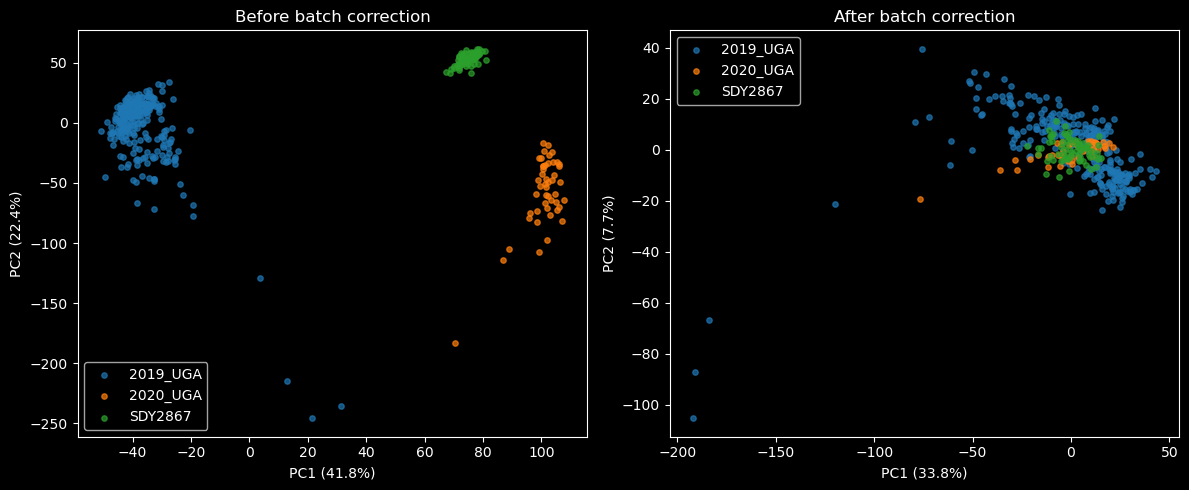

In [28]:
batch_series = pd.Series(batch)
unique_batches = batch_series.unique()
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(
        axes,
        [expr_df.T, corrected_df.T],
        ['Before batch correction', 'After batch correction']
):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(data.values)
    for i, b in enumerate(unique_batches):
        mask = (batch_series == b).values
        ax.scatter(coords[mask, 0], coords[mask, 1], label=b, alpha=0.7, s=15, color=colors[i])
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
# df_pivot = log_standard_scale(df_pivot)
# print(df_pivot.shape)
# peek(df_pivot)

In [10]:
os.makedirs(CLEAN_DATA_PATH, exist_ok=True)
df_pivot.to_parquet(CLEAN_DATA_PATH + '/transcriptomics_combined_cleaned.parquet', index=False)